# Import Libraries

In [1]:
import os
import math
import time
import random
import shutil
import itertools
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import brevitas.nn as qnn
from brevitas.nn import QuantLinear, QuantReLU, QuantConv2d
from brevitas.quant.binary import SignedBinaryActPerTensorConst
from brevitas.quant.binary import SignedBinaryWeightPerTensorConst
from brevitas.inject.enum import QuantType
from brevitas.quant_tensor.int_quant_tensor import IntQuantTensor
from brevitas.function.ops_ste import round_ste

# Network Definition

#### Neuron number and precision in each layer listed in this area for the MLP used in MNIST classification

In [2]:
kernel_num_CONV_layer_0_0 = 64
kernel_num_CONV_layer_0_1 = 64

kernel_num_CONV_layer_1_0 = 128
kernel_num_CONV_layer_1_1 = 128

kernel_num_CONV_layer_2_0 = 256
kernel_num_CONV_layer_2_1 = 256

neuron_num_FC_layer_0 = 512
neuron_num_FC_layer_1 = 512
neuron_num_OUT_layer  = 10

#### Hyperparameters setting here.

In [3]:
epochs = 200
batch_sizes = [128]
dropout_rates = [0.0, 0.05, 0.1]
lr_max_pool = [0.1, 0.05, 0.02, 0.01]
lr_min_pool = [1e-4]

#### GPU selection. After decided which GPU to train, don't change it before completing the training

In [4]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [5]:
GPU_device = "cuda:1"

#### Training date output folder path, for different network model setting, please change the name of save_path

In [6]:
save_path     = "CNV_float"

project_root  = os.path.abspath(".")
dataset_root  = os.path.join(project_root, "dataset/CIFAR10")
train_root    = os.path.join(project_root, "train")
output_root   = os.path.join(train_root, save_path)
report_root  = os.path.join(project_root, "report")

print("Dataset Download Path: ", dataset_root, "\n")
print("Training Data Output Path: ", output_root, "\n")
print("Training Report Output Path: ", report_root)

os.makedirs(dataset_root, exist_ok=True)
os.makedirs(output_root, exist_ok=True)
os.makedirs(report_root, exist_ok=True)

Dataset Download Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/CIFAR10/Baseline/dataset/CIFAR10 

Training Data Output Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/CIFAR10/Baseline/train/CNV_float 

Training Report Output Path:  /home/yuhao/project/QModels-Brevitas-Example/brevitas_std_qnn/classification/CIFAR10/Baseline/report


#### Following are the code to complete the network definition

In [7]:
kernel_size      = (3,3) 

In [8]:
in_channel_0_0   = 3
out_channel_0_0  = kernel_num_CONV_layer_0_0 
in_channel_0_1   = kernel_num_CONV_layer_0_0
out_channel_0_1  = kernel_num_CONV_layer_0_1 

in_channel_1_0   = kernel_num_CONV_layer_0_1
out_channel_1_0  = kernel_num_CONV_layer_1_0
in_channel_1_1   = kernel_num_CONV_layer_1_0
out_channel_1_1  = kernel_num_CONV_layer_1_1 

in_channel_2_0   = kernel_num_CONV_layer_1_1
out_channel_2_0  = kernel_num_CONV_layer_2_0
in_channel_2_1   = kernel_num_CONV_layer_2_0
out_channel_2_1  = kernel_num_CONV_layer_2_1 

input_length     = 4*4*kernel_num_CONV_layer_2_1

hidden_0         = neuron_num_FC_layer_0  
hidden_1         = neuron_num_FC_layer_1

output_length    = neuron_num_OUT_layer 

In [9]:
class CNV(nn.Module):
    def __init__(self, dropout=0.5):
        super(CNV, self).__init__()
        
        self.conv0_0 = nn.Conv2d(
                         in_channels=in_channel_0_0,
                         out_channels=out_channel_0_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn0_0   = nn.BatchNorm2d(out_channel_0_0)
        self.act0_0  = nn.ReLU()
        self.drop0_0 = nn.Dropout2d(dropout)
        
        self.conv0_1 = nn.Conv2d( 
                         in_channels=in_channel_0_1,
                         out_channels=out_channel_0_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn0_1   = nn.BatchNorm2d(out_channel_0_1)
        self.act0_1  = nn.ReLU()
        self.drop0_1 = nn.Dropout2d(dropout)
        
        self.pool0   = nn.MaxPool2d(2)
        
        self.conv1_0 = nn.Conv2d( 
                         in_channels=in_channel_1_0,
                         out_channels=out_channel_1_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn1_0   = nn.BatchNorm2d(out_channel_1_0)
        self.act1_0  = nn.ReLU()
        self.drop1_0 = nn.Dropout2d(dropout)
        
        self.conv1_1 = nn.Conv2d( 
                         in_channels=in_channel_1_1,
                         out_channels=out_channel_1_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn1_1   = nn.BatchNorm2d(out_channel_1_1)
        self.act1_1  = nn.ReLU()
        self.drop1_1 = nn.Dropout2d(dropout)
        
        self.pool1   = nn.MaxPool2d(2)
        
        self.conv2_0 = nn.Conv2d( 
                         in_channels=in_channel_2_0,
                         out_channels=out_channel_2_0,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn2_0   = nn.BatchNorm2d(out_channel_2_0)
        self.act2_0  = nn.ReLU()
        self.drop2_0 = nn.Dropout2d(dropout)
        
        self.conv2_1 = nn.Conv2d( 
                         in_channels=in_channel_2_1,
                         out_channels=out_channel_2_1,
                         kernel_size=kernel_size, 
                         stride=1, 
                         padding=1)
        self.bn2_1   = nn.BatchNorm2d(out_channel_2_1)
        self.act2_1  = nn.ReLU()
        self.drop2_1 = nn.Dropout2d(dropout)
        
        self.pool2   = nn.MaxPool2d(2)
        
        self.fc3     = nn.Linear(
                         input_length, 
                         hidden_0)
        self.bn3     = nn.BatchNorm1d(hidden_0)
        self.act3    = nn.ReLU()
        self.drop3   = nn.Dropout(dropout)
        
        self.fc4     = nn.Linear(
                         hidden_0, 
                         hidden_1)
        self.bn4     = nn.BatchNorm1d(hidden_1)
        self.act4    = nn.ReLU()
        self.drop4   = nn.Dropout(dropout)
        
        self.out     = nn.Linear(
                         hidden_1, 
                         output_length)

    def forward(self, x):

        out = self.drop0_0(self.act0_0(self.bn0_0(self.conv0_0(x))))
        out = self.drop0_1(self.act0_1(self.bn0_1(self.conv0_1(out))))
            
        out = self.pool0(out)
        
        out = self.drop1_0(self.act1_0(self.bn1_0(self.conv1_0(out))))
        out = self.drop1_1(self.act1_1(self.bn1_1(self.conv1_1(out))))
        
        out = self.pool1(out)
        
        out = self.drop2_0(self.act2_0(self.bn2_0(self.conv2_0(out))))
        out = self.drop2_1(self.act2_1(self.bn2_1(self.conv2_1(out))))
        
        out = self.pool2(out)
        
        out = out.reshape(out.shape[0], -1)

        out = self.drop3(self.act3(self.bn3(self.fc3(out))))
        out = self.drop4(self.act4(self.bn4(self.fc4(out))))
        out = self.out(out)
        
        return out

# Random Seed Utility

In [10]:
def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Define Dataloader

In [11]:
test_batch_size = 4096

In [12]:
def get_dataloaders(batch_size):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        ),
    ])

    transform_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2023, 0.1994, 0.2010)
        ),
    ])

    full_train_for_train = datasets.CIFAR10(
        dataset_root,
        train=True,
        download=True,
        transform=transform_train,
    )

    full_train_for_val = datasets.CIFAR10(
        dataset_root,
        train=True,
        download=True,
        transform=transform_eval,
    )

    test_dataset = datasets.CIFAR10(
        dataset_root,
        train=False,
        download=True,
        transform=transform_eval,
    )

    num_train = len(full_train_for_train)
    indices = torch.randperm(num_train).tolist()

    val_size = int(0.2 * num_train)
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    train_set = Subset(full_train_for_train, train_indices)
    val_set = Subset(full_train_for_val, val_indices)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=6,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=6,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=6,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=4,
    )

    return train_loader, val_loader, test_loader

# Evaluation Pipeline

In [13]:
def evaluate(model, criterion, device, loader, train):
    model.eval()
    loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        if (train):
            for x, y in loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
        else:
            for x, y in tqdm(loader, desc="Evaluation", leave=True):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                loss_total += loss.item() * x.size(0)
                _, pred = out.max(1)
                correct += (pred == y).sum().item()
                total += x.size(0)
    return loss_total / total, correct / total

# Plot Training Loss and Accuracy

In [14]:
def plot_train(history, save_dir):
    # Plot and show
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "training_plot.png"))
    plt.show()

# Training, Validation, and Testing Pipeline

In [15]:
def train_validate_test(config, save_dir):
    set_random_seed()
    os.makedirs(save_dir, exist_ok=True)
    log_file = os.path.join(save_dir, "training_log.txt")
    resume_path = os.path.join(save_dir, "checkpoint.pth")
    csv_log_path = os.path.join(save_dir, "training_log.csv")
    with open(csv_log_path, "a") as f:
        if os.path.getsize(csv_log_path) == 0:
            f.write("Epoch,Learning Rate,Train Loss,Train Acc,Val Loss,Val Acc,Epoch Time,Train Time,Val Time\n")

    epochs, batch_size, lr_max, lr_min, dropout = config
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr_max, momentum=0.9, weight_decay=5e-4)

    start_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": [], "train_time": [], "val_time": []}

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(device)
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"🔄 Resuming from epoch {start_epoch}")
    else:
        with open(log_file, "w") as f:
            f.write("Training started\n")

    # Training Loop
    t = trange(start_epoch, epochs, desc="Training", leave=True, ncols=150)
    for epoch in t:
        epoch_start = time.time()
        model.train()
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * epoch / epochs))
        for g in optimizer.param_groups:
            g["lr"] = lr

        train_start = time.time()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            _, pred = out.max(1)
            correct += (pred == y).sum().item()
            total += x.size(0)
        train_time = time.time() - train_start

        val_start = time.time()
        val_loss, val_acc = evaluate(model, criterion, device, val_loader, train=False)
        val_time = time.time() - val_start
        train_loss /= total
        train_acc = correct / total
        epoch_time = time.time() - epoch_start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time/60)
        history["train_time"].append(train_time/60)
        history["val_time"].append(val_time/60)

        log_line = (f"Epoch {epoch+1}/{epochs} - LR: {lr:.6f} | "
                    f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
                    f"Epoch Time: {epoch_time/60:.2f}, Train Time: {train_time/60:.2f}, Val Time: {val_time/60:.2f}")
        
        with open(log_file, "a") as f:
            f.write(log_line + "\n")

        
        with open(os.path.join(save_dir, "training_log.csv"), "a") as f:
            f.write(f"{epoch+1},{lr:.6f},{train_loss:.4f},{train_acc:.4f},{val_loss:.4f},{val_acc:.4f},{epoch_time/60:.4f},{train_time/60:.4f},{val_time/60:.4f}\n")

        t.set_description("| LR: %.6f | Train Acc: %.4f | Val Acc: %.4f | Epoch Time: %.2f | " % (lr, train_acc, val_acc, epoch_time/60))
        t.refresh()

        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history": history
        }, resume_path)

    # Plot and show the training history
    plot_train(history, save_dir)

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = f"Original Model Final Test Loss: {original_test_loss:.4f} Accuracy: {original_test_acc:.4f}"
    print(final_line)
    with open(log_file, "a") as f:
        f.write("Training completed\n")
        f.write(final_line + "\n")

    # Save the trained model
    torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
    with open(log_file, "a") as f:
        f.write(final_line + "\n")
    print("\n")

    return original_test_acc, resume_path

# Hyperparameter Searching for Network Training and Testing

In [16]:
def Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
    
    epochs = epochs
    batch_sizes = batch_sizes
    lr_max_pool = lr_max_pool
    lr_min_pool = lr_min_pool
    
    all_runs = [
        f"batch{bs}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        for bs, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)
    ]
    
    completed_runs = []
    for run in all_runs:
        log_path = os.path.join(output_root, run, "training_log.txt")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                if any("Training completed" in line for line in f):
                    completed_runs.append(run)
    
    if len(completed_runs) == len(all_runs):
        print("✅ All combinations completed. No retraining will be started.")
        print("ℹ️ If you want to retrain from scratch, please manually delete the previous training records/checkpoints.")
        completed_runs = []
    
    results = []
    for batch_size, lr_max, lr_min, dropout in itertools.product(batch_sizes, lr_max_pool, lr_min_pool, dropout_rates):
        run_name = f"batch{batch_size}_lr_max_{lr_max}_min_{lr_min}_dp{dropout}"
        save_dir = os.path.join(output_root, run_name)
    
        if run_name in completed_runs:
            print(f"✅ Skipping {run_name}")
            with open(os.path.join(save_dir, "training_log.txt")) as f:
                for line in f:
                    if "Final Test Loss" in line:
                        acc = float(line.strip().split()[-1])
                        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout, os.path.join(save_dir, "checkpoint.pth")))
            continue
    
        print(f"🚀 Running: {run_name}")
        acc, resume_path = train_validate_test([epochs, batch_size, lr_max, lr_min, dropout], save_dir)
        results.append((run_name, acc, epochs, batch_size, lr_max, lr_min, dropout, resume_path))
    
    results.sort(key=lambda x: x[1], reverse=True)
    best_config, best_acc, best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path = results[0]
    
    with open(os.path.join(report_root, save_path+"_report.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Accuracy\n")
        for name, acc, epoch, batch_size, lr_max, lr_min, dropout, resume_path in results:
            f.write(f"{epoch},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{acc:.4f}\n")
            
    return best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path

In [17]:
def best_evaluation(epochs, batch_size, lr_max, lr_min, dropout, resume_path):
    set_random_seed()

    epochs, batch_size, lr_max, lr_min, dropout = epochs, batch_size, lr_max, lr_min, dropout
    train_loader, val_loader, test_loader = get_dataloaders(batch_size)
    device = torch.device(GPU_device if torch.cuda.is_available() else "cpu")
    model = CNV(dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr_max, momentum=0.9, weight_decay=5e-4)

    if os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location="cpu")
        model.load_state_dict(ckpt["model_state"])
        model.to(device)
        optimizer.load_state_dict(ckpt["optimizer_state"])
        history = ckpt["history"]
        print("Best model loaded.")
    else:
        print("Best model lost.")

    # Test the original trained model
    original_test_loss, original_test_acc = evaluate(model, criterion, device, test_loader, train=False)
    final_line = (
        f"Best Original Model Final Test Loss: {original_test_loss:.4f} "
        f"Acc: {original_test_acc:.4f} "
    )
    print(final_line)
    print("\n")

    with open(os.path.join(report_root, save_path + "_best_eval.csv"), "w") as f:
        f.write("Epoch,Batch Size,LR_max,LR_min,Dropout,Acc,Loss\n")
        f.write(f"{epochs},{batch_size},{lr_max:.4f},{lr_min:.6f},{dropout:.4f},{original_test_acc:.4f},{original_test_loss:.4f}\n")

✅ All combinations completed. No retraining will be started.
ℹ️ If you want to retrain from scratch, please manually delete the previous training records/checkpoints.
🚀 Running: batch128_lr_max_0.1_min_0.0001_dp0.0
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


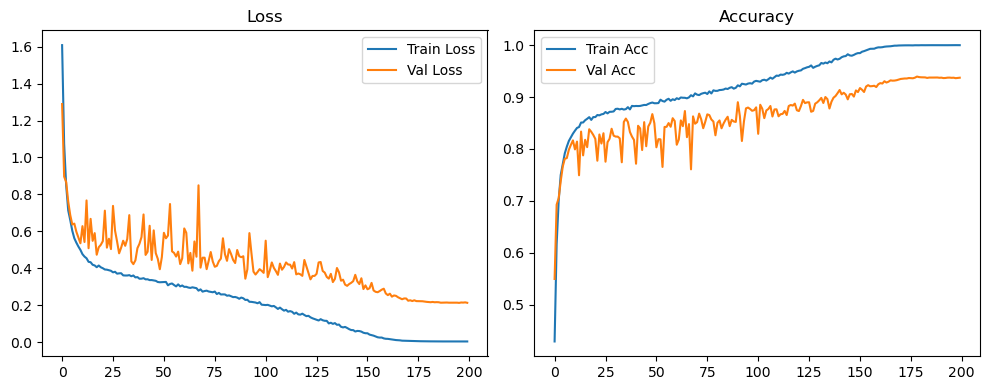

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.41it/s]


Original Model Final Test Loss: 0.2196 Accuracy: 0.9351


🚀 Running: batch128_lr_max_0.1_min_0.0001_dp0.05
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


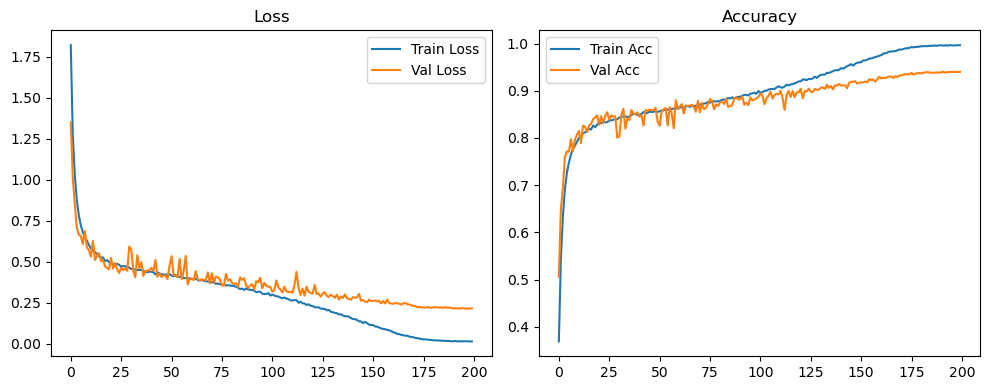

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.64it/s]


Original Model Final Test Loss: 0.2255 Accuracy: 0.9351


🚀 Running: batch128_lr_max_0.1_min_0.0001_dp0.1
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


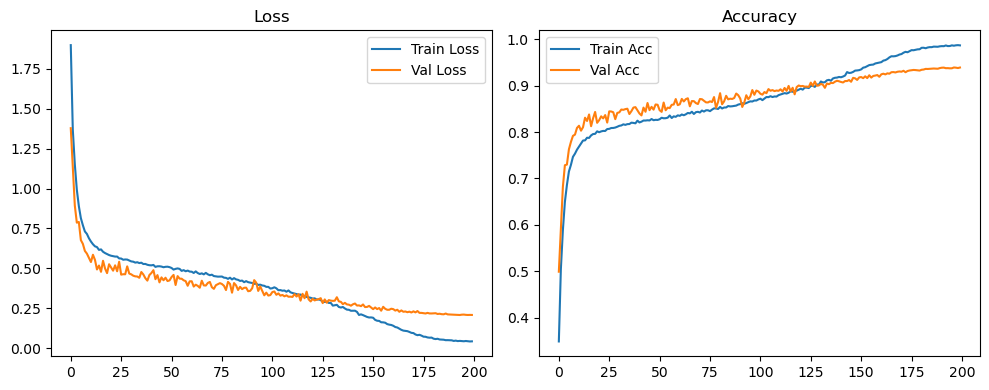

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.60it/s]


Original Model Final Test Loss: 0.2312 Accuracy: 0.9319


🚀 Running: batch128_lr_max_0.05_min_0.0001_dp0.0
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


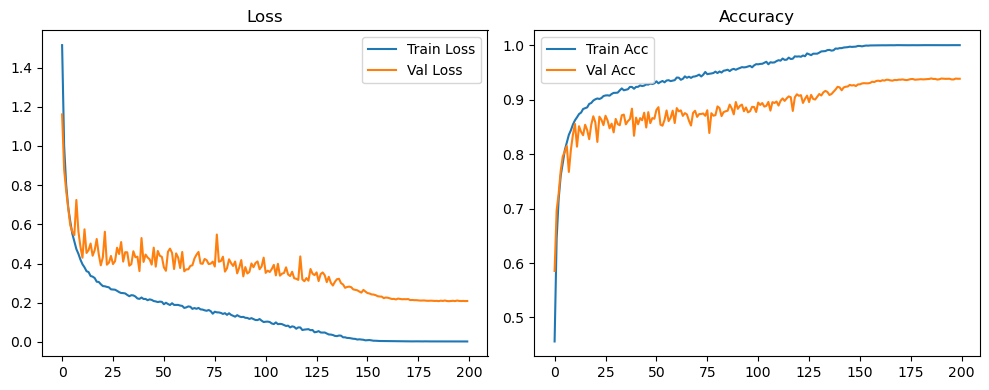

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.58it/s]


Original Model Final Test Loss: 0.2239 Accuracy: 0.9344


🚀 Running: batch128_lr_max_0.05_min_0.0001_dp0.05
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


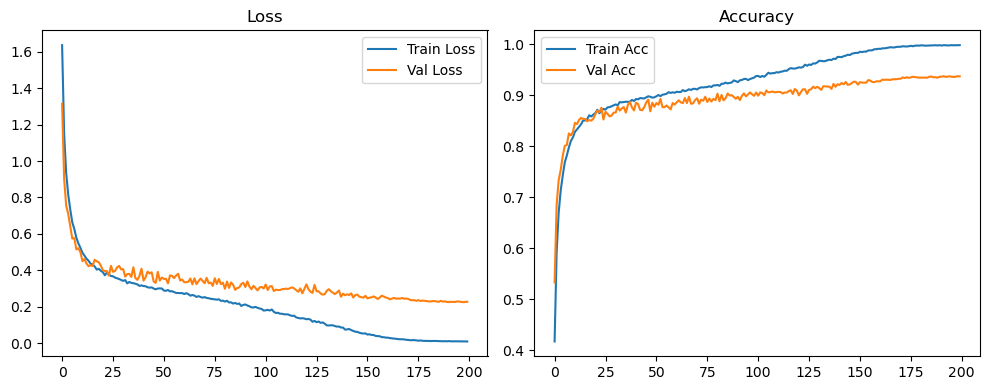

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.65it/s]


Original Model Final Test Loss: 0.2285 Accuracy: 0.9324


🚀 Running: batch128_lr_max_0.05_min_0.0001_dp0.1
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


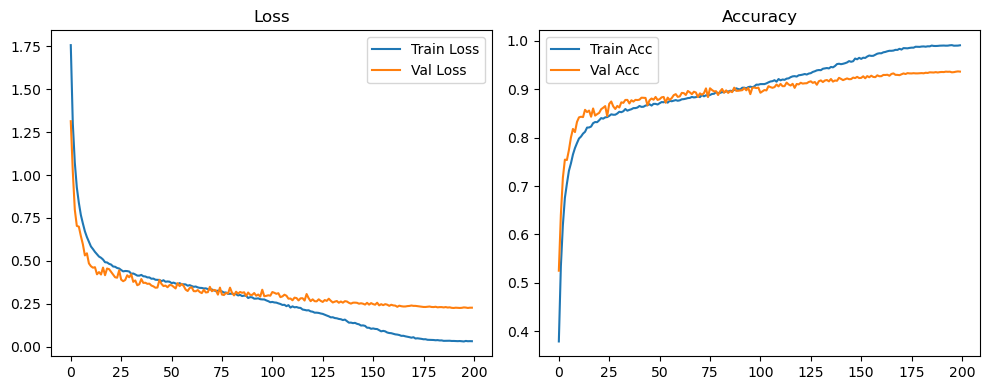

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.57it/s]


Original Model Final Test Loss: 0.2356 Accuracy: 0.9321


🚀 Running: batch128_lr_max_0.02_min_0.0001_dp0.0
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


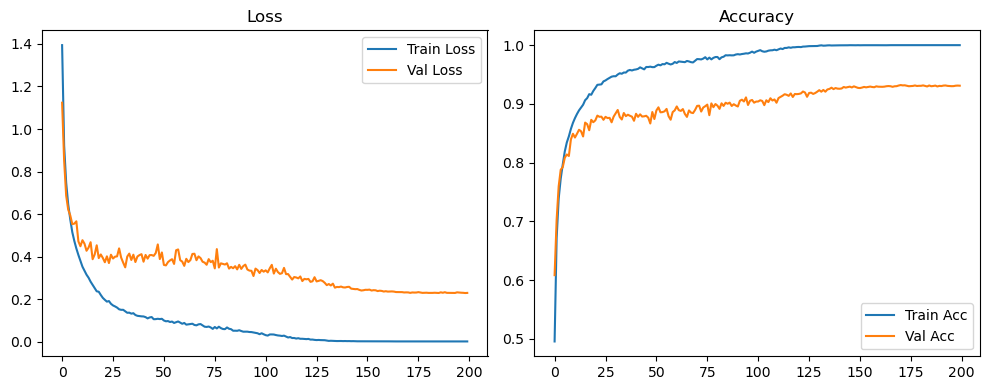

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.32it/s]


Original Model Final Test Loss: 0.2404 Accuracy: 0.9263


🚀 Running: batch128_lr_max_0.02_min_0.0001_dp0.05
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


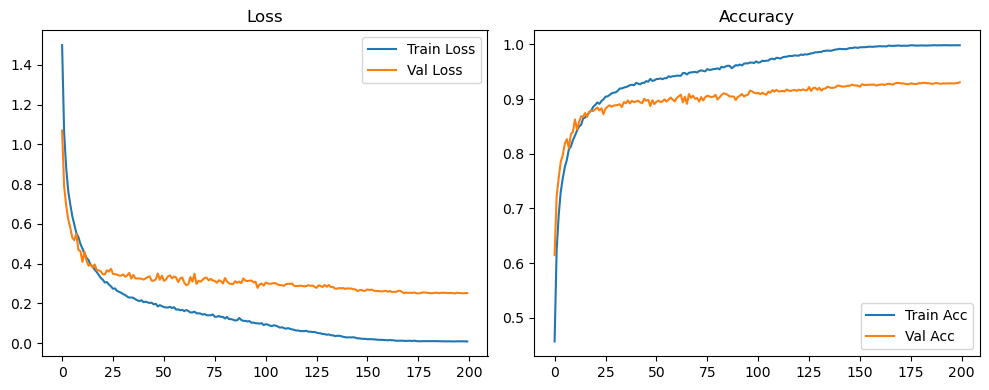

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.55it/s]


Original Model Final Test Loss: 0.2554 Accuracy: 0.9267


🚀 Running: batch128_lr_max_0.02_min_0.0001_dp0.1
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


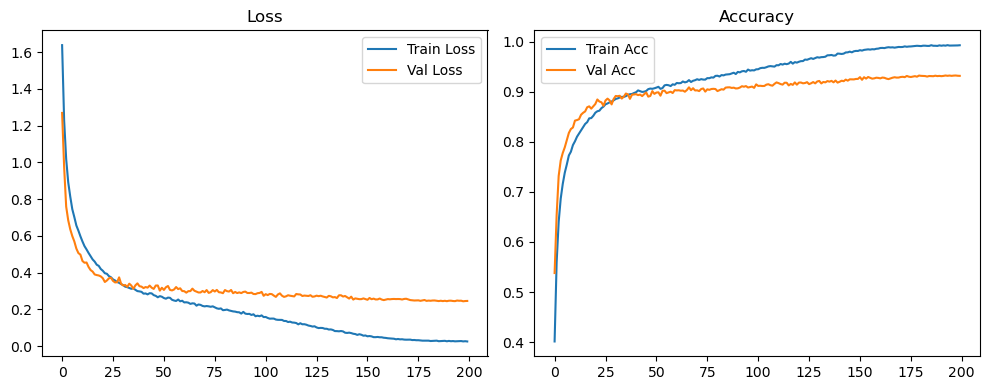

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.56it/s]


Original Model Final Test Loss: 0.2555 Accuracy: 0.9274


🚀 Running: batch128_lr_max_0.01_min_0.0001_dp0.0
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


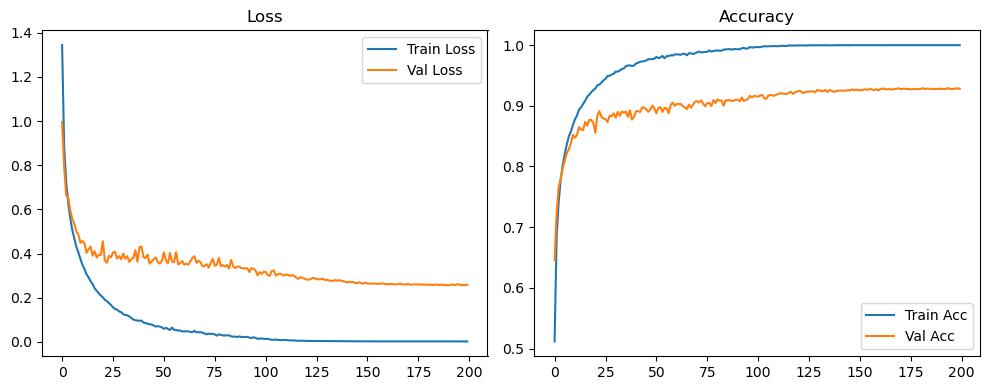

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.54it/s]


Original Model Final Test Loss: 0.2755 Accuracy: 0.9213


🚀 Running: batch128_lr_max_0.01_min_0.0001_dp0.05
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


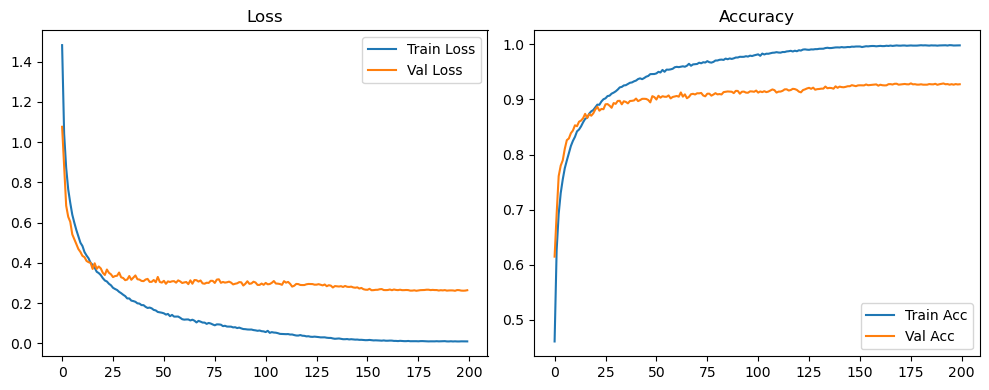

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.55it/s]


Original Model Final Test Loss: 0.2819 Accuracy: 0.9219


🚀 Running: batch128_lr_max_0.01_min_0.0001_dp0.1
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
🔄 Resuming from epoch 200


Training: 0it [00:00, ?it/s]


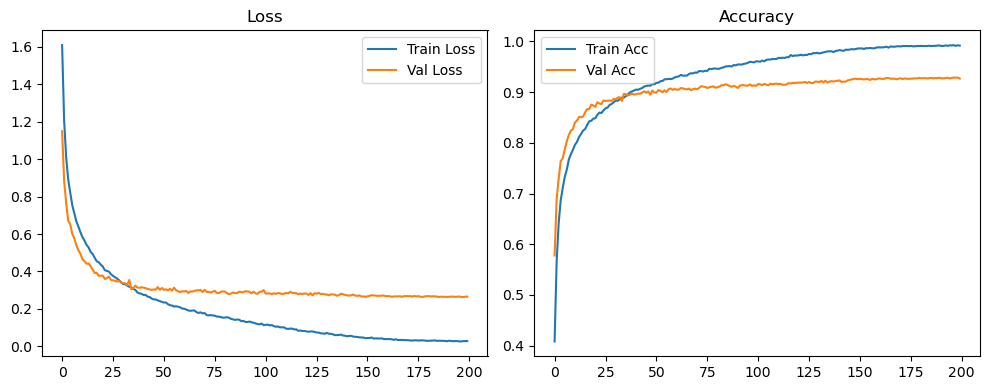

Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.52it/s]


Original Model Final Test Loss: 0.2722 Accuracy: 0.9230




| LR: 0.096492 | Train Acc: 0.8674 | Val Acc: 0.8302 | Epoch Time: 0.06 | :   7%|██▋                                 | 14/190 [00:56<10:30,  3.58s/it]

| LR: 0.096492 | Train Acc: 0.8674 | Val Acc: 0.8302 | Epoch Time: 0.06 | :   8%|██▊                                 | 15/190 [00:56<10:29,  3.60s/it]

| LR: 0.096198 | Train Acc: 0.8711 | Val Acc: 0.7754 | Epoch Time: 0.06 | :   8%|██▊                                 | 15/190 [00:59<10:29,  3.60s/it]

...

| LR: 0.000125 | Train Acc: 0.9999 | Val Acc: 0.9368 | Epoch Time: 0.06 | :  99%|██████████████████████████████████▊| 189/190 [11:16<00:03,  3.52s/it]

| LR: 0.000106 | Train Acc: 0.9999 | Val Acc: 0.9372 | Epoch Time: 0.06 | :  99%|██████████████████████████████████▊| 189/190 [11:19<00:03,  3.52s/it]

| LR: 0.000106 | Train Acc: 0.9999 | Val Acc: 0.9372 | Epoch Time: 0.06 | :  99%|██████████████████████████████████▊| 189/190 [11:19<00:03,  3.52s/it]

| LR: 0.000106 | Train Acc: 0.9999 | Val Acc: 0.9372 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 190/190 [11:19<00:00,  3.51s/it]

| LR: 0.000106 | Train Acc: 0.9999 | Val Acc: 0.9372 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 190/190 [11:19<00:00,  3.58s/it]

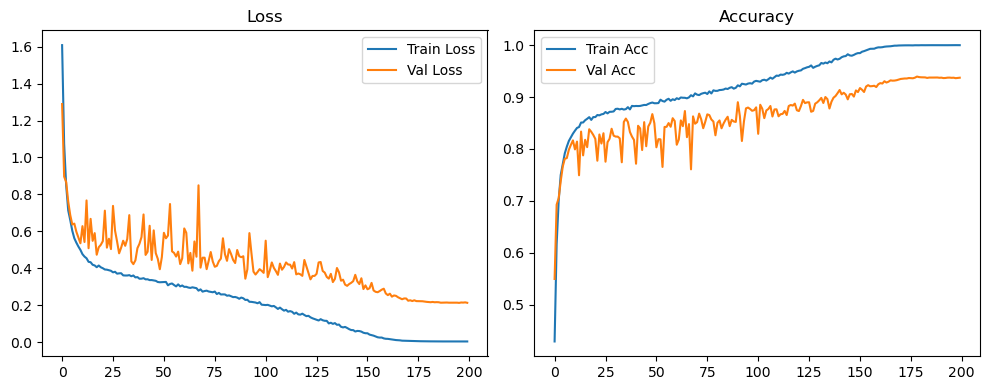

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.25s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.71it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.19it/s]

Original Model Final Test Loss: 0.2196 Accuracy: 0.9351




...

| LR: 0.000125 | Train Acc: 0.9962 | Val Acc: 0.9396 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:38<00:03,  3.81s/it]

| LR: 0.000106 | Train Acc: 0.9965 | Val Acc: 0.9399 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:41<00:03,  3.81s/it]

| LR: 0.000106 | Train Acc: 0.9965 | Val Acc: 0.9399 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:41<00:03,  3.81s/it]

| LR: 0.000106 | Train Acc: 0.9965 | Val Acc: 0.9399 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:41<00:00,  3.80s/it]

| LR: 0.000106 | Train Acc: 0.9965 | Val Acc: 0.9399 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:41<00:00,  3.81s/it]

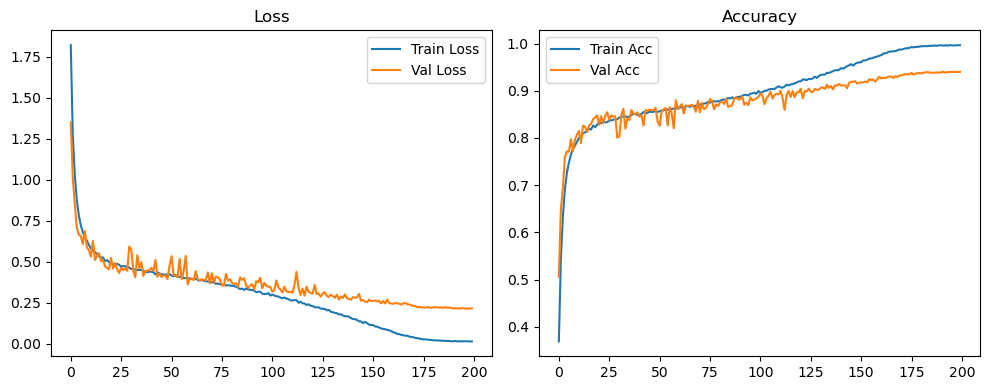

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.19s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.84it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.29it/s]

Original Model Final Test Loss: 0.2255 Accuracy: 0.9351




...

| LR: 0.000125 | Train Acc: 0.9872 | Val Acc: 0.9379 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:42<00:03,  3.82s/it]

| LR: 0.000106 | Train Acc: 0.9868 | Val Acc: 0.9390 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:45<00:03,  3.82s/it]

| LR: 0.000106 | Train Acc: 0.9868 | Val Acc: 0.9390 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:45<00:03,  3.82s/it]

| LR: 0.000106 | Train Acc: 0.9868 | Val Acc: 0.9390 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:45<00:00,  3.82s/it]

| LR: 0.000106 | Train Acc: 0.9868 | Val Acc: 0.9390 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:45<00:00,  3.83s/it]

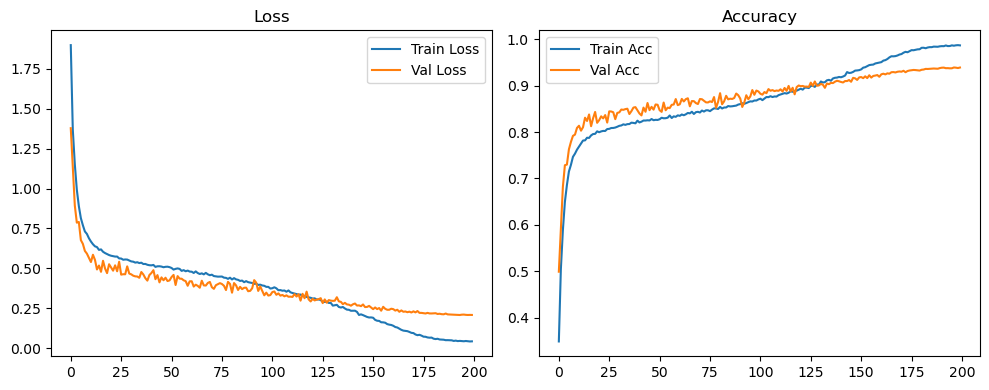

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.24s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.72it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.19it/s]

Original Model Final Test Loss: 0.2312 Accuracy: 0.9319




...

| LR: 0.000112 | Train Acc: 1.0000 | Val Acc: 0.9383 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [11:53<00:03,  3.59s/it]

| LR: 0.000103 | Train Acc: 1.0000 | Val Acc: 0.9383 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [11:56<00:03,  3.59s/it]

| LR: 0.000103 | Train Acc: 1.0000 | Val Acc: 0.9383 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [11:56<00:03,  3.59s/it]

| LR: 0.000103 | Train Acc: 1.0000 | Val Acc: 0.9383 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [11:56<00:00,  3.58s/it]

| LR: 0.000103 | Train Acc: 1.0000 | Val Acc: 0.9383 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [11:56<00:00,  3.58s/it]

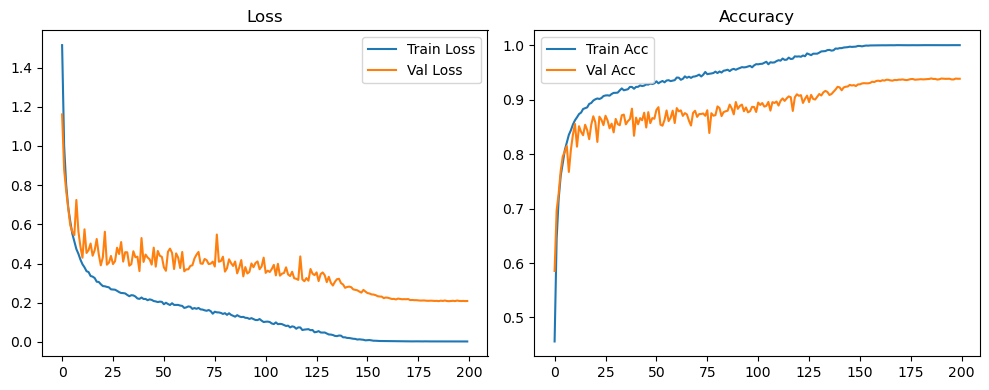

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.30s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.62it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.11it/s]

Original Model Final Test Loss: 0.2239 Accuracy: 0.9344




...

| LR: 0.000112 | Train Acc: 0.9978 | Val Acc: 0.9372 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:48<00:03,  3.82s/it]

| LR: 0.000103 | Train Acc: 0.9980 | Val Acc: 0.9368 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:51<00:03,  3.82s/it]

| LR: 0.000103 | Train Acc: 0.9980 | Val Acc: 0.9368 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:51<00:03,  3.82s/it]

| LR: 0.000103 | Train Acc: 0.9980 | Val Acc: 0.9368 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:51<00:00,  3.83s/it]

| LR: 0.000103 | Train Acc: 0.9980 | Val Acc: 0.9368 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:51<00:00,  3.86s/it]

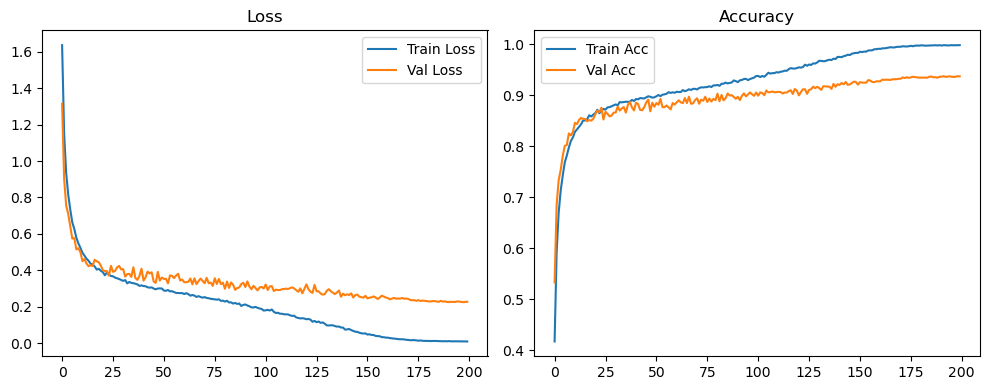

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.24s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.73it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.20it/s]

Original Model Final Test Loss: 0.2285 Accuracy: 0.9324




...

| LR: 0.000112 | Train Acc: 0.9902 | Val Acc: 0.9369 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:47<00:03,  3.86s/it]

| LR: 0.000103 | Train Acc: 0.9909 | Val Acc: 0.9365 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.86s/it]

| LR: 0.000103 | Train Acc: 0.9909 | Val Acc: 0.9365 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.86s/it]

| LR: 0.000103 | Train Acc: 0.9909 | Val Acc: 0.9365 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.84s/it]

| LR: 0.000103 | Train Acc: 0.9909 | Val Acc: 0.9365 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.85s/it]

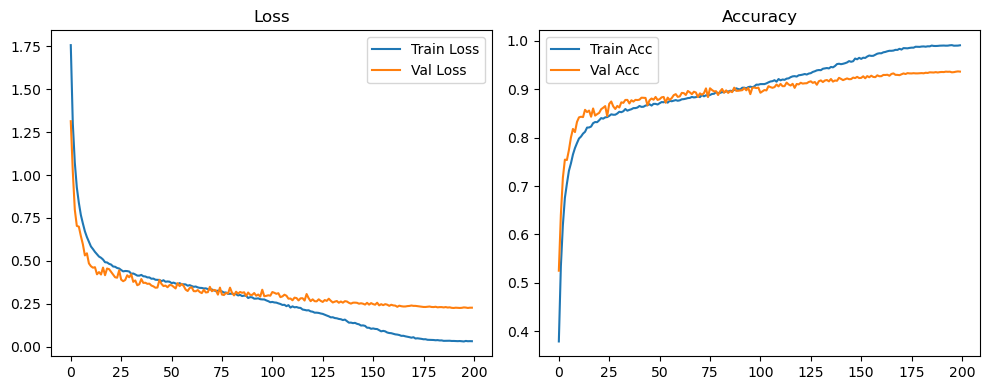

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.47s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.35it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.89it/s]

Original Model Final Test Loss: 0.2356 Accuracy: 0.9321




...

| LR: 0.000105 | Train Acc: 1.0000 | Val Acc: 0.9312 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:10<00:03,  3.77s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9310 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:14<00:03,  3.77s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9310 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:14<00:03,  3.77s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9310 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:14<00:00,  3.71s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9310 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:14<00:00,  3.67s/it]

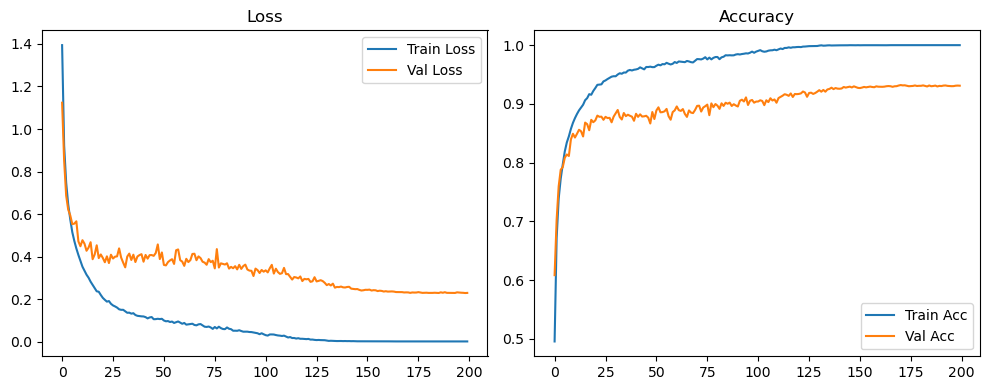

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.25s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.69it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.17it/s]

Original Model Final Test Loss: 0.2404 Accuracy: 0.9263




...

| LR: 0.000105 | Train Acc: 0.9983 | Val Acc: 0.9293 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:46<00:03,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9984 | Val Acc: 0.9306 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9984 | Val Acc: 0.9306 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9984 | Val Acc: 0.9306 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9984 | Val Acc: 0.9306 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.85s/it]

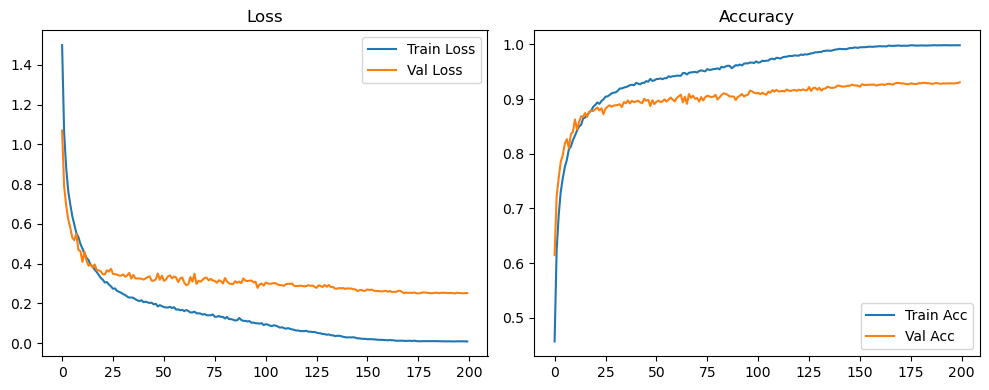

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.25s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.70it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.18it/s]

Original Model Final Test Loss: 0.2554 Accuracy: 0.9267




...

| LR: 0.000105 | Train Acc: 0.9926 | Val Acc: 0.9320 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:47<00:03,  3.86s/it]

| LR: 0.000101 | Train Acc: 0.9929 | Val Acc: 0.9318 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.86s/it]

| LR: 0.000101 | Train Acc: 0.9929 | Val Acc: 0.9318 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.86s/it]

| LR: 0.000101 | Train Acc: 0.9929 | Val Acc: 0.9318 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.84s/it]

| LR: 0.000101 | Train Acc: 0.9929 | Val Acc: 0.9318 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.85s/it]

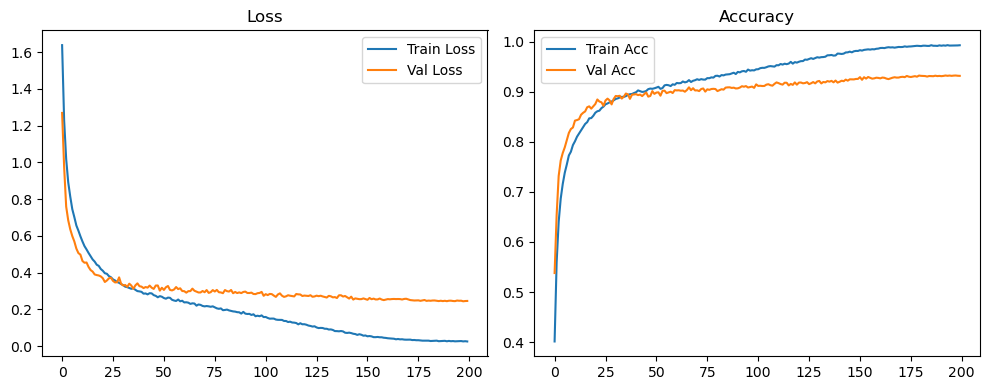

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.27s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.67it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.15it/s]

Original Model Final Test Loss: 0.2555 Accuracy: 0.9274




...

| LR: 0.000102 | Train Acc: 1.0000 | Val Acc: 0.9290 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [11:53<00:03,  3.57s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9280 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [11:56<00:03,  3.57s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9280 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [11:56<00:03,  3.57s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9280 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [11:56<00:00,  3.57s/it]

| LR: 0.000101 | Train Acc: 1.0000 | Val Acc: 0.9280 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [11:56<00:00,  3.58s/it]

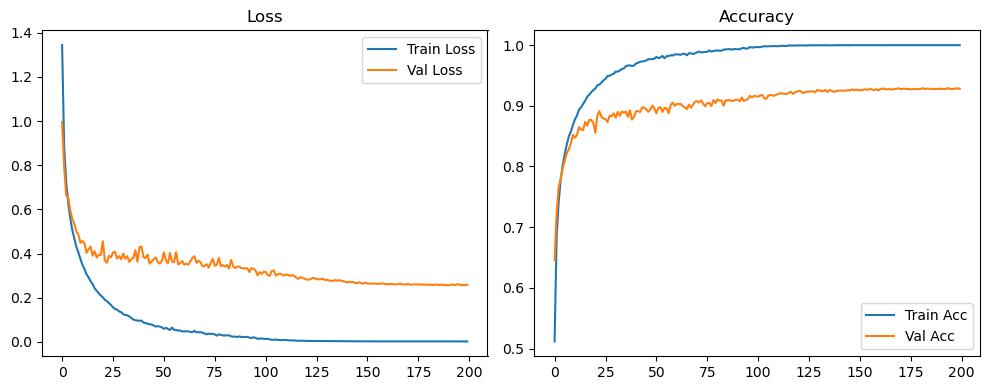

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.24s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.72it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.20it/s]

Original Model Final Test Loss: 0.2755 Accuracy: 0.9213




...

| LR: 0.000102 | Train Acc: 0.9979 | Val Acc: 0.9271 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:46<00:03,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9980 | Val Acc: 0.9275 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9980 | Val Acc: 0.9275 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:50<00:03,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9980 | Val Acc: 0.9275 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.85s/it]

| LR: 0.000101 | Train Acc: 0.9980 | Val Acc: 0.9275 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:50<00:00,  3.85s/it]

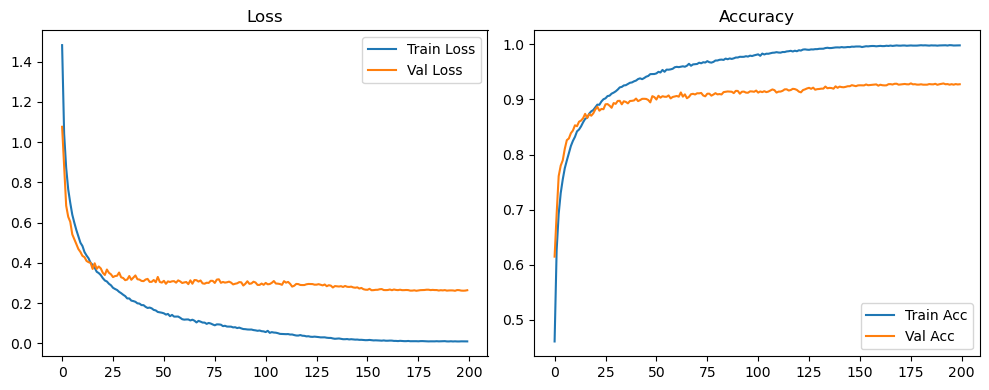

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.29s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.63it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.12it/s]

Original Model Final Test Loss: 0.2819 Accuracy: 0.9219




...

| LR: 0.000102 | Train Acc: 0.9925 | Val Acc: 0.9287 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:47<00:03,  3.83s/it]

| LR: 0.000101 | Train Acc: 0.9919 | Val Acc: 0.9269 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:51<00:03,  3.83s/it]

| LR: 0.000101 | Train Acc: 0.9919 | Val Acc: 0.9269 | Epoch Time: 0.06 | : 100%|██████████████████████████████████▊| 199/200 [12:51<00:03,  3.83s/it]

| LR: 0.000101 | Train Acc: 0.9919 | Val Acc: 0.9269 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:51<00:00,  3.83s/it]

| LR: 0.000101 | Train Acc: 0.9919 | Val Acc: 0.9269 | Epoch Time: 0.06 | : 100%|███████████████████████████████████| 200/200 [12:51<00:00,  3.86s/it]

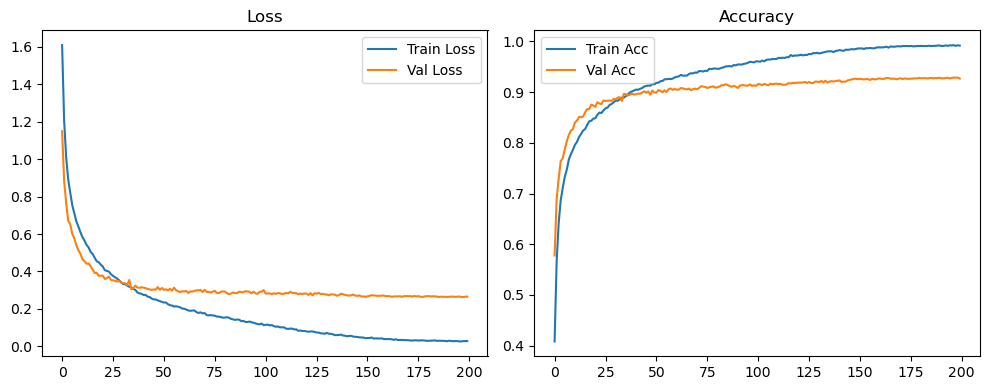

Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.25s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.71it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.18it/s]

Original Model Final Test Loss: 0.2722 Accuracy: 0.9230




In [18]:
best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path  = Hyperparameter_searching(epochs, batch_sizes, lr_max_pool, lr_min_pool, dropout_rates)

In [19]:
best_evaluation(best_epochs, best_batch_size, best_lr_max, best_lr_min, best_dropout, best_resume_path)

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Best model loaded.


Evaluation: 100%|█████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.47it/s]


Best Original Model Final Test Loss: 0.2196 Acc: 0.9351 




Best model loaded.


Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluation:  33%|███▎      | 1/3 [00:01<00:02,  1.36s/it]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.51it/s]

Evaluation: 100%|██████████| 3/3 [00:01<00:00,  2.02it/s]

Best Original Model Final Test Loss: 0.2196 Acc: 0.9351 


